In [ ]:
# 06_model_evaluation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [3]:
rfm = pd.read_csv("../data/rfm_with_clv.csv")

In [4]:
features = rfm[['Recency','Frequency','Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

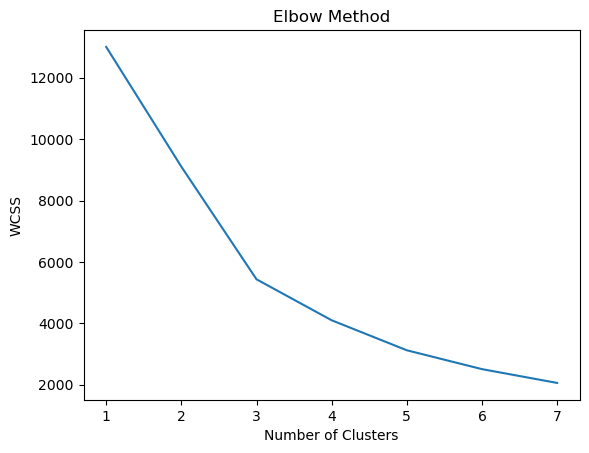

In [5]:
wcss = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,8), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [6]:
for k in range(2,8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.9214714693310809
K=3, Silhouette Score=0.5940014908816534
K=4, Silhouette Score=0.6162696093073907
K=5, Silhouette Score=0.604173839146124
K=6, Silhouette Score=0.5960466176699958
K=7, Silhouette Score=0.5186191670308722
